Cell 1 — Imports + Reproducibility

In [10]:
import os, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("TF:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)


TF: 2.13.0


In [11]:
TRAIN_DIR = "../dataset/train"
VAL_DIR   = "../dataset/validation"
TEST_DIR  = "../dataset/test"


Cell 3 — Your Custom Preprocessing (CLAHE + Blur + Normalize)

In [12]:
import cv2

IMG_SIZE = 224

def custom_preprocessing(img):
    # img: RGB float array from generator (0..255)
    img = img.astype(np.uint8)

    # RGB -> Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    # Gaussian Blur
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    # Normalize [0,1]
    gray = gray.astype(np.float32) / 255.0

    # Convert back to 3-channel (VGG16 expects 3 channels)
    out = np.stack([gray, gray, gray], axis=-1)
    return out


Cell 4 — Data Generators (Augment ONLY Train)

In [13]:
BATCH_SIZE = 8

train_gen = ImageDataGenerator(
    preprocessing_function=custom_preprocessing,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=(0.85, 1.15),
    horizontal_flip=True
)

val_gen = ImageDataGenerator(preprocessing_function=custom_preprocessing)
test_gen = ImageDataGenerator(preprocessing_function=custom_preprocessing)

train_gen = ImageDataGenerator(
    preprocessing_function=custom_preprocessing,
    rotation_range=7,
    zoom_range=0.08,
    width_shift_range=0.03,
    height_shift_range=0.03,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True
)


val_data = val_gen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary"
)

test_data = test_gen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary",
    shuffle=False
)

print("Class indices:", train_data.class_indices)


Found 235 images belonging to 2 classes.


Found 437 images belonging to 2 classes.
Class indices: {'Normal': 0, 'Stroke': 1}


Cell 5 — Class Weights (Use Your Values)

In [14]:
class_weights = {0: 0.8477460901563938, 1: 1.218915343915344}
class_weights


{0: 0.8477460901563938, 1: 1.218915343915344}

Cell 6 — Build VGG16 Model (Transfer Learning)

In [15]:
base = VGG16(
    include_top=False,
    weights="imagenet",
    input_tensor=Input(shape=(IMG_SIZE, IMG_SIZE, 3))
)

base.trainable = False  # freeze all conv layers

x = GlobalAveragePooling2D()(base.output)
x = Dense(512, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.2)(x)
output = Dense(1, activation="sigmoid")(x)


model = Model(inputs=base.input, outputs=output)
model.summary()


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0   

Cell 7 — Compile

In [16]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)


Cell 8 — Callbacks (Prevents Overfitting + Saves Best)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import os

os.makedirs("../models", exist_ok=True)

callbacks = [
    ModelCheckpoint(
        filepath="../models/vgg16_best.h5",   # <-- change to .h5
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]


Cell 9 — Train (Phase 1: Head Only)

In [18]:
EPOCHS = 25  # CPU-safe start

history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/25
116/116 [==============================] - ETA: 0s - loss: 0.7112 - accuracy: 0.5100 - precision: 0.4249 - recall: 0.5503 - auc: 0.5140
Epoch 1: val_auc improved from -inf to 0.59918, saving model to ../models\vgg16_best.h5


c:\Users\admin\Desktop\Brain_Stroke_Project\stroke_env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


116/116 [==============================] - 376s 3s/step - loss: 0.7112 - accuracy: 0.5100 - precision: 0.4249 - recall: 0.5503 - auc: 0.5140 - val_loss: 0.6723 - val_accuracy: 0.6638 - val_precision: 0.3333 - val_recall: 0.0128 - val_auc: 0.5992 - lr: 1.0000e-04
Epoch 2/25
116/116 [==============================] - ETA: 0s - loss: 0.7053 - accuracy: 0.5084 - precision: 0.4163 - recall: 0.4934 - auc: 0.5036
Epoch 2: val_auc improved from 0.59918 to 0.66916, saving model to ../models\vgg16_best.h5
116/116 [==============================] - 427s 4s/step - loss: 0.7053 - accuracy: 0.5084 - precision: 0.4163 - recall: 0.4934 - auc: 0.5036 - val_loss: 0.6823 - val_accuracy: 0.6426 - val_precision: 0.4667 - val_recall: 0.5385 - val_auc: 0.6692 - lr: 1.0000e-04
Epoch 3/25
116/116 [==============================] - ETA: 0s - loss: 0.6901 - accuracy: 0.5496 - precision: 0.4544 - recall: 0.4881 - auc: 0.5549
Epoch 3: val_auc improved from 0.66916 to 0.68198, saving model to ../models\vgg16_best.h

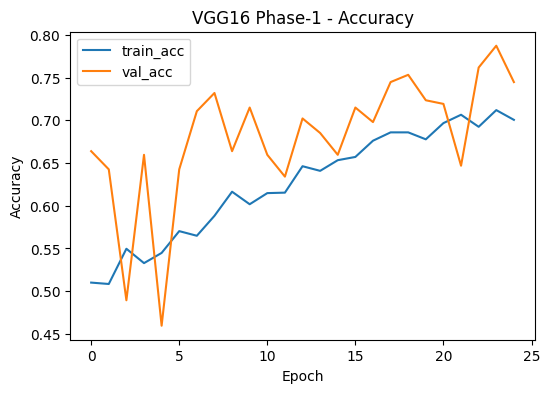

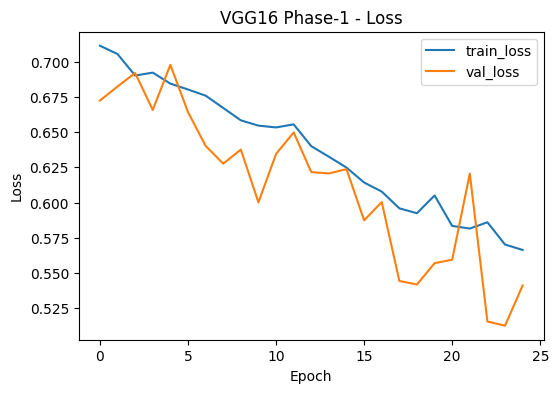

In [19]:
def plot_history(hist, title="Training"):
    h = hist.history
    plt.figure(figsize=(6,4))
    plt.plot(h["accuracy"], label="train_acc")
    plt.plot(h["val_accuracy"], label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(h["loss"], label="train_loss")
    plt.plot(h["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_history(history1, "VGG16 Phase-1")


In [ ]:
Cell 11 — Evaluate on Test Set (Also screenshot)

In [20]:
test_metrics = model.evaluate(test_data, verbose=1)
print(dict(zip(model.metrics_names, test_metrics)))


55/55 [==============================] - 48s 863ms/step - loss: 0.5704 - accuracy: 0.6979 - precision: 0.4942 - recall: 0.6538 - auc: 0.7473
{'loss': 0.5704469680786133, 'accuracy': 0.6979405283927917, 'precision': 0.49418604373931885, 'recall': 0.6538461446762085, 'auc': 0.747268795967102}


In [21]:
import numpy as np

# Reset generator just in case
test_data.reset()

# Get prediction probabilities
y_prob = model.predict(test_data, verbose=1)

# Convert probabilities to class labels (0/1)
y_pred = (y_prob > 0.5).astype(int).ravel()

# True labels
y_true = test_data.classes

print("Pred shape:", y_pred.shape)
print("True shape:", y_true.shape)


55/55 [==============================] - 76s 1s/step
Pred shape: (437,)
True shape: (437,)


In [22]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[220  87]
 [ 45  85]]


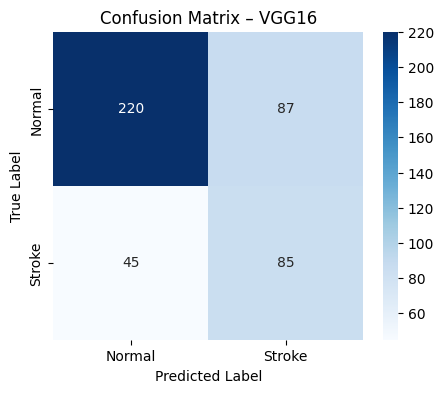

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Stroke"],
    yticklabels=["Normal", "Stroke"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – VGG16")
plt.show()


In [24]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

roc_auc


0.7474317213730894

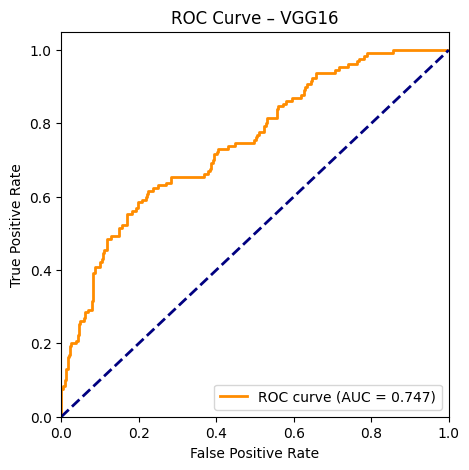

In [25]:
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"ROC curve (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – VGG16")
plt.legend(loc="lower right")
plt.show()
